In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv('exoplanet_data.csv', comment='#')

print(df.head())

print(f"\nTotal planets loaded: {len(df)}")

      pl_name  pl_orbsmax  st_teff
0    11 Com b       1.178   4874.0
1    11 UMi b       1.530   4213.0
2    14 And b       0.775   4888.0
3    14 Her b       2.839   5338.0
4  16 Cyg B b       1.660   5750.0

Total planets loaded: 6273


In [11]:
df_clean = df.dropna(subset=['st_teff', 'pl_orbsmax']).copy()

# M-type: 2000K to 3900K, G-type: 5200K to 6000K
temp_mask = ((df_clean['st_teff'] >= 2000) & (df_clean['st_teff'] <= 3900)) | \
            ((df_clean['st_teff'] >= 5200) & (df_clean['st_teff'] <= 6000))

dist_mask = (df_clean['pl_orbsmax'] <= 2.0)

df_final = df_clean[temp_mask & dist_mask].copy()

print(f"Dataset cleaned. We now have {len(df_final)} planets to analyze.")

Dataset cleaned. We now have 2863 planets to analyze.


In [12]:
def categorize_star(temp):
    if 2000 <= temp <= 3900:
        return 'M-type'
    elif 5200 <= temp <= 6000:
        return 'G-type'
    return 'Other'

df_final['spectral_class'] = df_final['st_teff'].apply(categorize_star)

print(df_final['spectral_class'].value_counts())

spectral_class
G-type    2364
M-type     499
Name: count, dtype: int64


In [13]:
analysis_results = df_final.groupby('spectral_class')['pl_orbsmax'].mean()

print("\n--- Final Analysis Results ---")
print("Average Orbital Distance (AU):")
print(analysis_results)


--- Final Analysis Results ---
Average Orbital Distance (AU):
spectral_class
G-type    0.190999
M-type    0.106177
Name: pl_orbsmax, dtype: float64


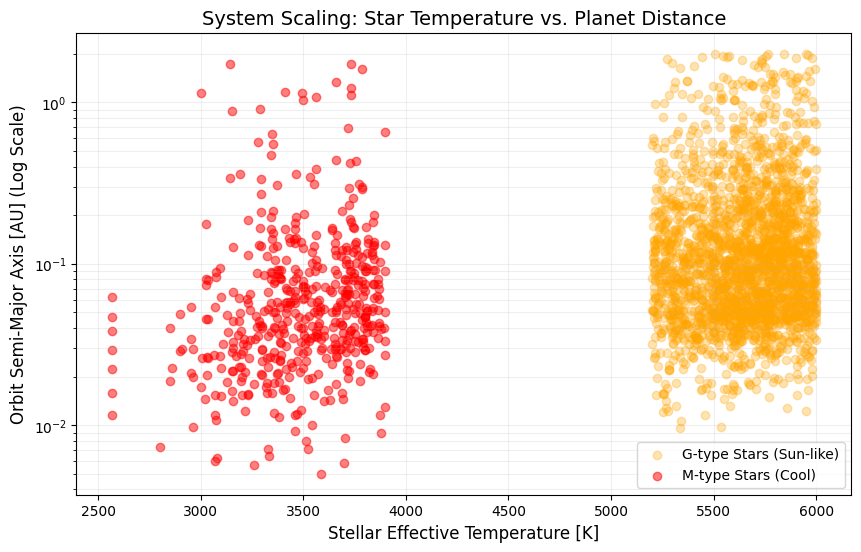

In [14]:
plt.figure(figsize=(10, 6))

m_stars = df_final[df_final['spectral_class'] == 'M-type']
g_stars = df_final[df_final['spectral_class'] == 'G-type']

plt.scatter(g_stars['st_teff'], g_stars['pl_orbsmax'], color='orange', alpha=0.3, label='G-type Stars (Sun-like)')
plt.scatter(m_stars['st_teff'], m_stars['pl_orbsmax'], color='red', alpha=0.5, label='M-type Stars (Cool)')

plt.yscale('log')

plt.xlabel('Stellar Effective Temperature [K]', fontsize=12)
plt.ylabel('Orbit Semi-Major Axis [AU] (Log Scale)', fontsize=12)
plt.title('System Scaling: Star Temperature vs. Planet Distance', fontsize=14)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.show()

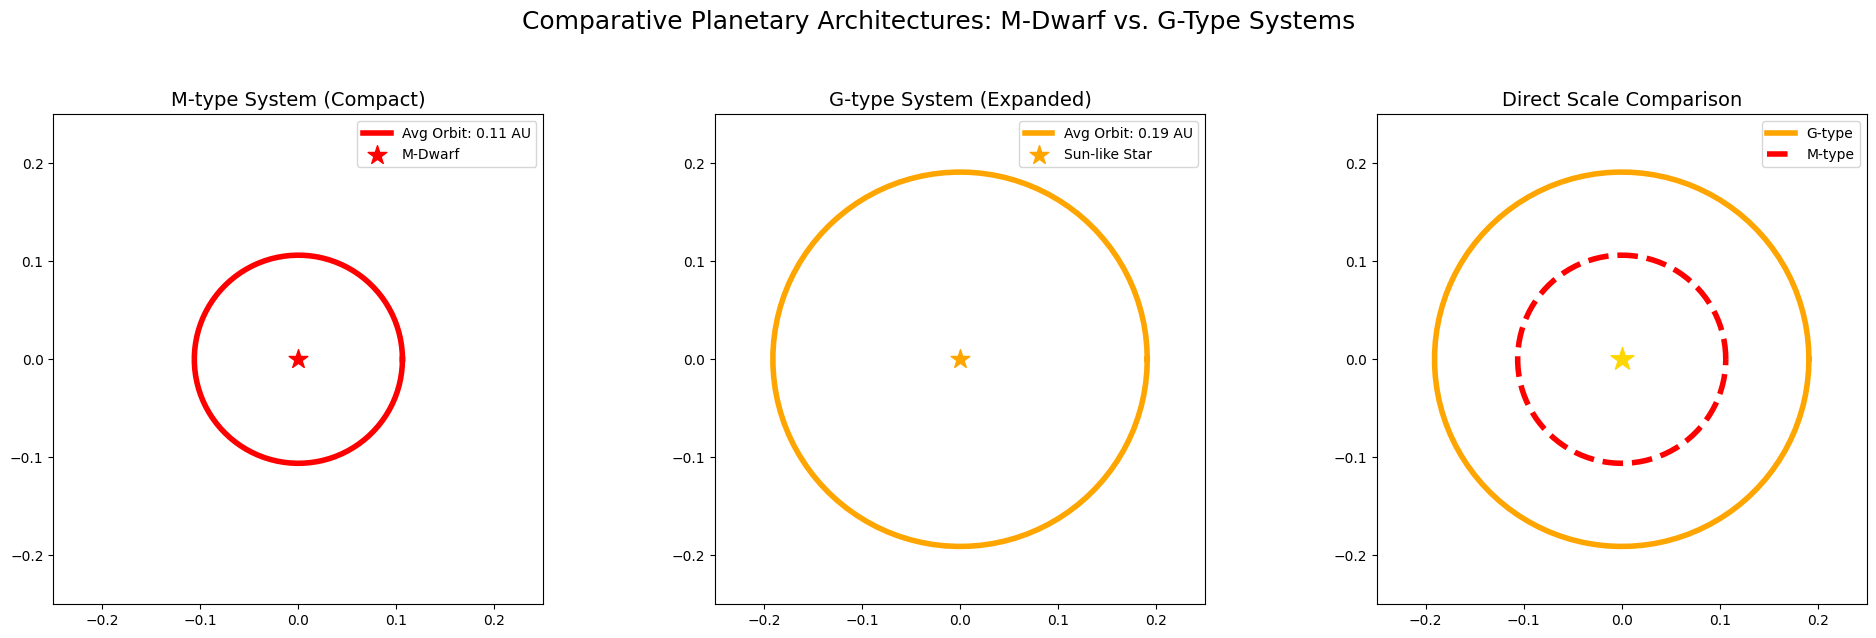

In [15]:
r_m = 0.106177  
r_g = 0.190999  

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
theta = np.linspace(0, 2 * np.pi, 100)

limit = 0.25 

ax1.plot(r_m * np.cos(theta), r_m * np.sin(theta), color='red', lw=4, label=f'Avg Orbit: {r_m:.2f} AU')
ax1.scatter(0, 0, color='red', marker='*', s=200, label='M-Dwarf')
ax1.set_title('M-type System (Compact)', fontsize=14)
ax1.set_xlim(-limit, limit)
ax1.set_ylim(-limit, limit)
ax1.set_aspect('equal')
ax1.legend(loc='upper right')

ax2.plot(r_g * np.cos(theta), r_g * np.sin(theta), color='orange', lw=4, label=f'Avg Orbit: {r_g:.2f} AU')
ax2.scatter(0, 0, color='orange', marker='*', s=200, label='Sun-like Star')
ax2.set_title('G-type System (Expanded)', fontsize=14)
ax2.set_xlim(-limit, limit)
ax2.set_ylim(-limit, limit)
ax2.set_aspect('equal')
ax2.legend(loc='upper right')

ax3.plot(r_g * np.cos(theta), r_g * np.sin(theta), color='orange', lw=4, label='G-type')
ax3.plot(r_m * np.cos(theta), r_m * np.sin(theta), color='red', lw=4, ls='--', label='M-type')
ax3.scatter(0, 0, color='gold', marker='*', s=300, zorder=5)
ax3.set_title('Direct Scale Comparison', fontsize=14)
ax3.set_xlim(-limit, limit)
ax3.set_ylim(-limit, limit)
ax3.set_aspect('equal')
ax3.legend(loc='upper right')

fig.suptitle('Comparative Planetary Architectures: M-Dwarf vs. G-Type Systems', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

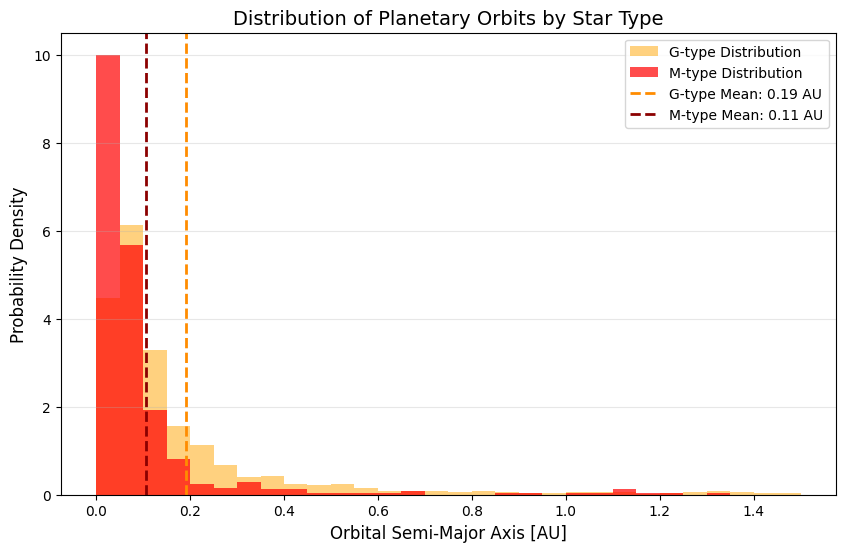

In [16]:
plt.figure(figsize=(10, 6))

plt.hist(g_stars['pl_orbsmax'], bins=30, range=(0, 1.5), alpha=0.5, color='orange', label='G-type Distribution', density=True)
plt.hist(m_stars['pl_orbsmax'], bins=30, range=(0, 1.5), alpha=0.7, color='red', label='M-type Distribution', density=True)

plt.axvline(r_g, color='darkorange', linestyle='dashed', linewidth=2, label=f'G-type Mean: {r_g:.2f} AU')
plt.axvline(r_m, color='darkred', linestyle='dashed', linewidth=2, label=f'M-type Mean: {r_m:.2f} AU')

plt.xlabel('Orbital Semi-Major Axis [AU]', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title('Distribution of Planetary Orbits by Star Type', fontsize=14)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()